<a href="https://colab.research.google.com/github/Edenshmuel/CrimeData/blob/main/Anomaly_detection.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Importing Required Libraries

In [1]:
import pandas as pd
import seaborn as sns
from matplotlib import rcParams
import matplotlib.pyplot as plt
from sklearn.ensemble import IsolationForest

Loading and Extracting Unupervised Datasets from GitHub Repository

In [2]:
import os
import zipfile

# Clone the dataset repository from GitHub
!git clone https://github.com/orifelszer/CrimeData.git

zip_folder = 'CrimeData'

# Define paths to the ZIP files
zip_files = [
    os.path.join(zip_folder, 'Clean_data_unsupervised_part1.zip'),
    os.path.join(zip_folder, 'Clean_data_unsupervised_part2.zip')
]

extracted_folders = []

# Extract ZIP files if they exist and were not previously extracted
for zip_file in zip_files:
    extract_path = zip_file.replace('.zip', '')

    if os.path.exists(zip_file):
        if not os.path.exists(extract_path):  #
            with zipfile.ZipFile(zip_file, 'r') as zip_ref:
                zip_ref.extractall(extract_path)
            print(f"Extracted: {zip_file} -> {extract_path}")
        else:
            print(f"Skipped: {zip_file} (Already extracted)")
    else:
        print(f"File not found: {zip_file}")

    extracted_folders.append(extract_path)


dataframes = []

# Load all CSV files from the extracted folders
for folder in extracted_folders:
    for file_name in os.listdir(folder):
        file_path = os.path.join(folder, file_name)
        if file_name.endswith('.csv'):
            df_temp = pd.read_csv(file_path)
            dataframes.append(df_temp)

combined_df = pd.concat(dataframes, ignore_index=True)

# Display dataset summary
print(f"Combined dataset contains {combined_df.shape[0]} rows and {combined_df.shape[1]} columns.")

Cloning into 'CrimeData'...
remote: Enumerating objects: 1031, done.
remote: Counting objects: 100% (281/281), done.
remote: Compressing objects: 100% (105/105), done.
remote: Total 1031 (delta 243), reused 176 (delta 176), pack-reused 750 (from 3)
Receiving objects: 100% (1031/1031), 302.16 MiB | 14.33 MiB/s, done.
Resolving deltas: 100% (545/545), done.
Extracted: CrimeData/Clean_data_unsupervised_part1.zip -> CrimeData/Clean_data_unsupervised_part1
Extracted: CrimeData/Clean_data_unsupervised_part2.zip -> CrimeData/Clean_data_unsupervised_part2
Combined dataset contains 1686927 rows and 19 columns.


Correlation Heatmap with Hebrew Support

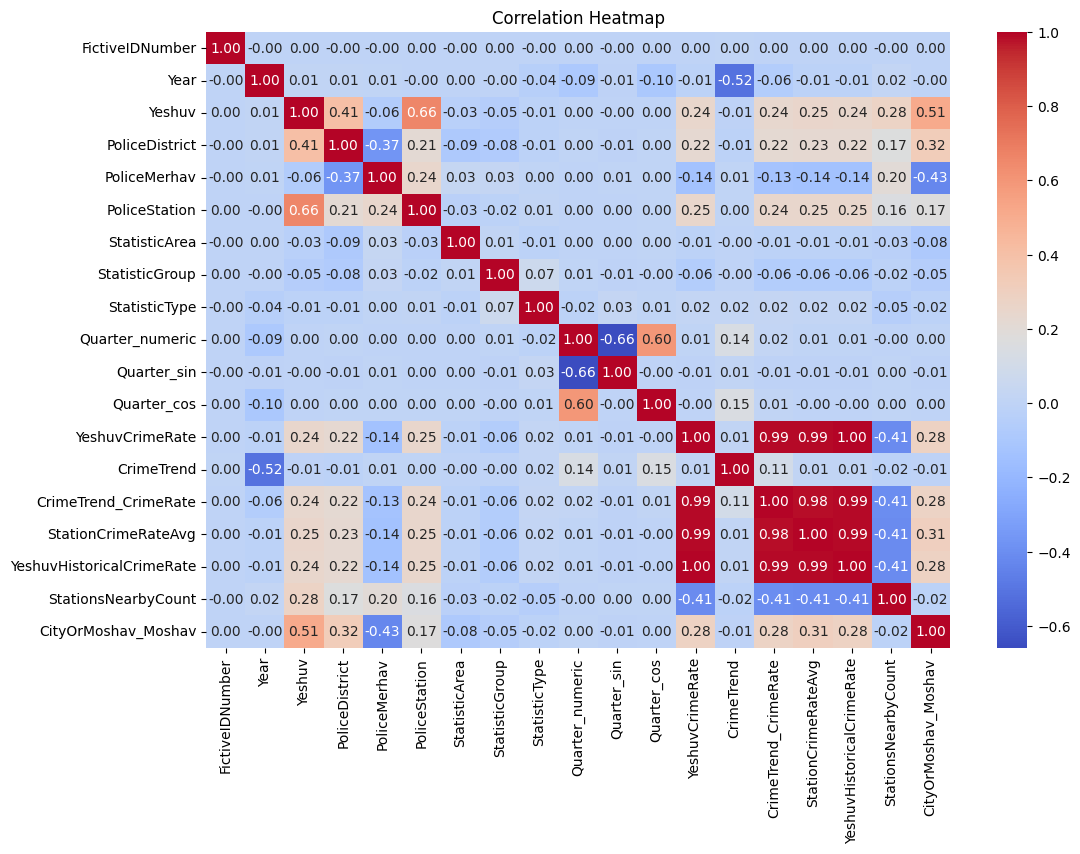

In [7]:
# Calculate correlation matrix for numerical variables
correlation_matrix = combined_df.corr()

# Create a heatmap to visualize correlations
plt.figure(figsize=(12, 8))
sns.heatmap(correlation_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Grouping by 'Yeshuv' and Calculating Metrics

In [8]:
# Aggregate data by 'Yeshuv' for crime rates, nearby stations, and crime trends
yeshuv_grouped = combined_df.groupby('Yeshuv').agg(
    YeshuvCrimeRateAvg=('YeshuvCrimeRate', 'mean'),
    StationsNearbyAvg=('StationsNearbyCount', 'mean'),
    CrimeTrendAvg=('CrimeTrend', 'mean')).reset_index()

# Normalize the crime rate by the average number of nearby stations
yeshuv_grouped['CrimeRateNormalized'] = (
    yeshuv_grouped['YeshuvCrimeRateAvg'] / yeshuv_grouped['StationsNearbyAvg'])

Sorting Localities by Crime Rate and Number of Stations

In [9]:
# Sort localities by descending crime rate and ascending number of stations
sorted_yeshuv = yeshuv_grouped.sort_values(
    by=['YeshuvCrimeRateAvg', 'StationsNearbyAvg'], ascending=[False, True])

# Display the top 10 localities with high crime rates and few stations
print("Top 10 Localities with Highest Crime Rate and Few Stations:")
print(sorted_yeshuv.head(10))

Top 10 Localities with Highest Crime Rate and Few Stations:
    Yeshuv  YeshuvCrimeRateAvg  StationsNearbyAvg  CrimeTrendAvg  \
80      80            2.490922           3.500010       4.646094   
33      33            2.364671           1.998603       4.761460   
8        8            1.184634           3.500010       4.706782   
25      25            0.975553           3.000010       4.702239   
70      70            0.625726           4.500010       4.627364   
57      57            0.617891           4.499673       4.651610   
50      50            0.596563           4.500010       4.657544   
6        6            0.523885           3.500010       4.687727   
24      24            0.487452           3.500246       4.597544   
14      14            0.485299           3.502782       4.630808   

    CrimeRateNormalized  
80             0.711690  
33             1.183162  
8              0.338466  
25             0.325183  
70             0.139050  
57             0.137319  
50       

Identifying Priority Localities Based on Crime Rate and Station Count

In [10]:
# Define thresholds for high crime rate and low station count
high_crime_threshold = yeshuv_grouped['YeshuvCrimeRateAvg'].mean()
low_station_threshold = yeshuv_grouped['StationsNearbyAvg'].mean()

# Filter priority localities
priority_yeshuvs = yeshuv_grouped[
    (yeshuv_grouped['YeshuvCrimeRateAvg'] > high_crime_threshold) &
    (yeshuv_grouped['StationsNearbyAvg'] < low_station_threshold)]

Loading Mapping Data and Merging with Priority Localities

In [11]:
# Define the path to the mapping file
mapping_file_path = os.path.join(zip_folder, 'Yeshuv_mapping_unsupervised.csv')

# Load the mapping file if it exists
if os.path.exists(mapping_file_path):
    mapping_data = pd.read_csv(mapping_file_path)
else:
    raise FileNotFoundError(f"Mapping file not found at {mapping_file_path}")


In [12]:
# Merge priority localities with the mapping data to retrieve locality names
priority_yeshuvs_with_names = pd.merge(
    priority_yeshuvs,
    mapping_data,
    left_on='Yeshuv',
    right_on='Encoded_Value',
    how='left')

Ensuring Correct Column Selection and Renaming for Priority Localities

In [13]:
# Select relevant columns and ensure proper naming
priority_yeshuvs_with_names = priority_yeshuvs_with_names[
    ['YeshuvCrimeRateAvg', 'StationsNearbyAvg', 'CrimeTrendAvg',
     'CrimeRateNormalized', 'Encoded_Value', 'Yeshuv_y']
].rename(columns={'Yeshuv_y': 'Locality_Name'})

priority_yeshuvs_with_names

,YeshuvCrimeRateAvg,StationsNearbyAvg,CrimeTrendAvg,CrimeRateNormalized,Encoded_Value,Locality_Name
0,0.310474,3.000010,4.674427,0.103491,23,חדרה
1,0.975553,3.000010,4.702239,0.325183,25,חיפה
2,2.364671,1.998603,4.761460,1.183162,33,ירושלים
3,0.239784,3.000010,4.675715,0.079928,52,עכו


Assigning Priority Levels and Visualizing Localities

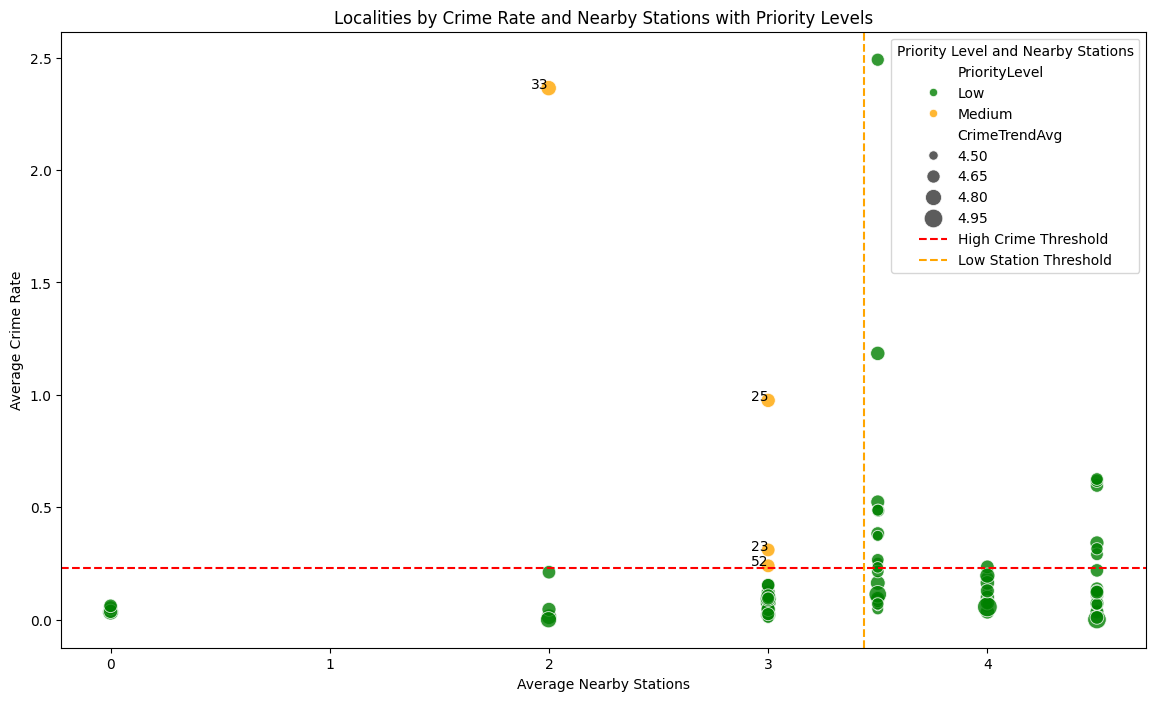

In [14]:
# Define threshold for high crime trend
high_trend_threshold = yeshuv_grouped['CrimeTrendAvg'].mean()

# Assign priority levels based on thresholds
yeshuv_grouped['PriorityLevel'] = 'Low'  # Default priority level

# High priority: High crime rate, low station count, and high trend
yeshuv_grouped.loc[
    (yeshuv_grouped['YeshuvCrimeRateAvg'] > high_crime_threshold) &
    (yeshuv_grouped['StationsNearbyAvg'] < low_station_threshold) &
    (yeshuv_grouped['CrimeTrendAvg'] > high_trend_threshold),
    'PriorityLevel'
] = 'High'

# Medium priority: High crime rate and low station count
yeshuv_grouped.loc[
    (yeshuv_grouped['YeshuvCrimeRateAvg'] > high_crime_threshold) &
    (yeshuv_grouped['StationsNearbyAvg'] < low_station_threshold),
    'PriorityLevel'
] = 'Medium'

# Define color mapping for priority levels
priority_colors = {
    'High': 'red',
    'Medium': 'orange',
    'Low': 'green'
}

# === Creating a Scatter Plot for Localities by Priority Level ===
plt.figure(figsize=(14, 8))
sns.scatterplot(
    x=yeshuv_grouped['StationsNearbyAvg'],
    y=yeshuv_grouped['YeshuvCrimeRateAvg'],
    hue=yeshuv_grouped['PriorityLevel'],
    size=yeshuv_grouped['CrimeTrendAvg'],
    sizes=(20, 200),
    palette=priority_colors,
    alpha=0.8
)

# Add threshold lines for better visualization
plt.axhline(high_crime_threshold, color='red', linestyle='--', label='High Crime Threshold')
plt.axvline(low_station_threshold, color='orange', linestyle='--', label='Low Station Threshold')

# Annotate points with high and medium priority using Hebrew support
for index, row in yeshuv_grouped.iterrows():
    if row['PriorityLevel'] in ['High', 'Medium']:
        plt.text(row['StationsNearbyAvg'], row['YeshuvCrimeRateAvg'], reverse_hebrew_text(row['Yeshuv']),
                 fontsize=10, ha='right')

# Titles and labels
plt.title("Localities by Crime Rate and Nearby Stations with Priority Levels")
plt.xlabel("Average Nearby Stations")
plt.ylabel("Average Crime Rate")
plt.legend(title="Priority Level and Nearby Stations")
plt.show()


*Yellow dots are flagged as high-priority targets for increasing police station coverage or other interventions to reduce crime.
We're continuing our analysis focusing in these localities.*


Visualizing Crime Rate and Station Relationships with RTL Support

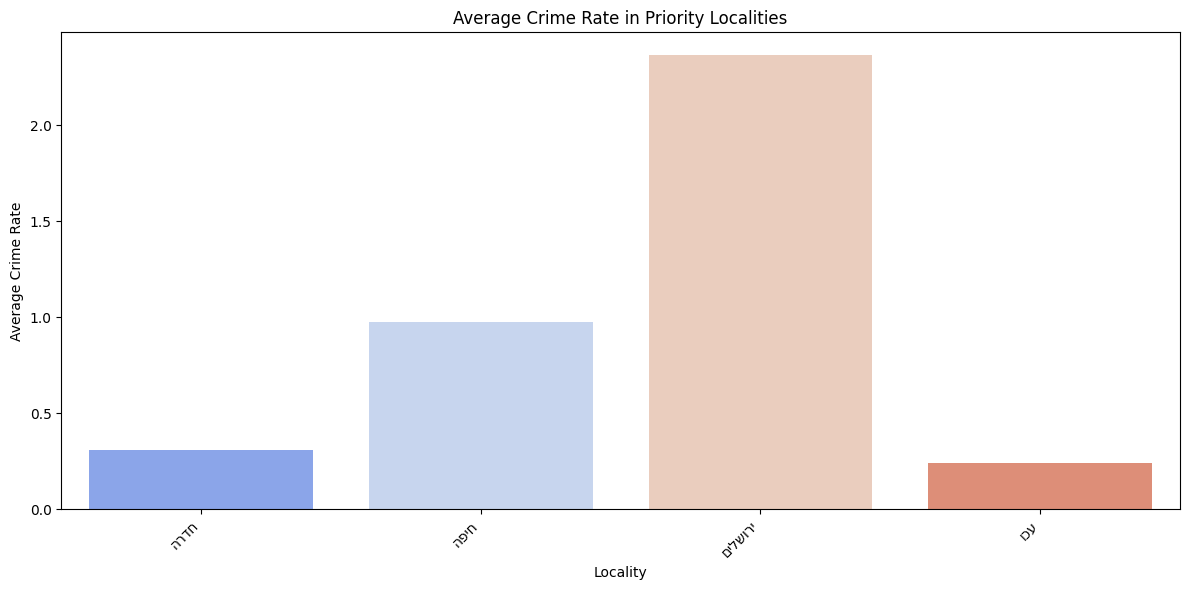

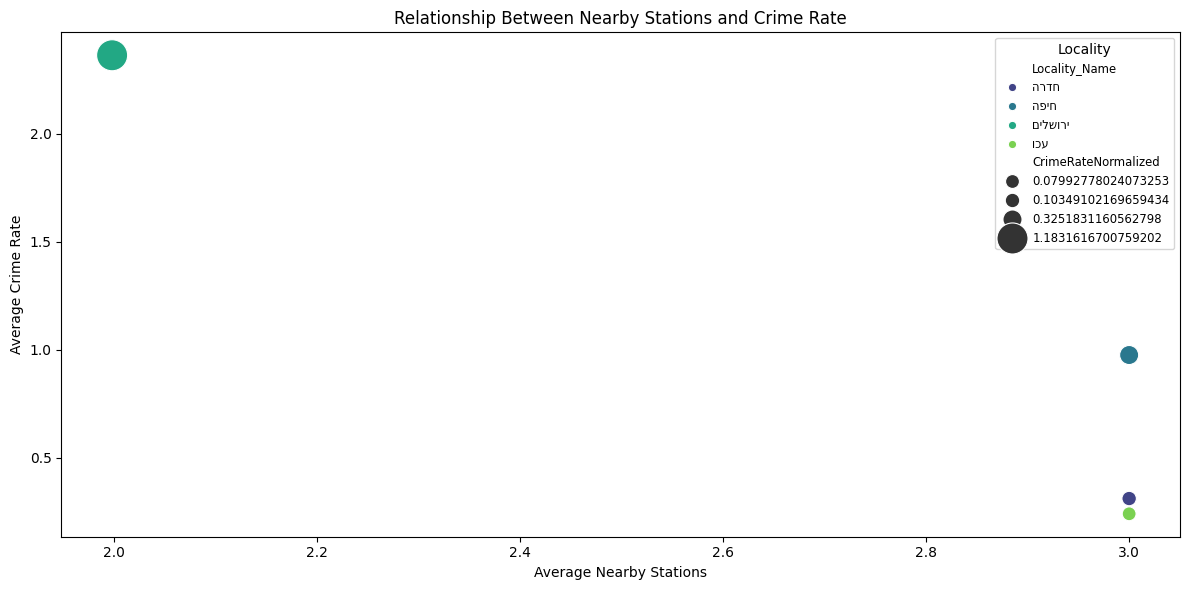

In [15]:
# Ensure Right-to-Left (RTL) support and proper Hebrew rendering
rcParams['text.usetex'] = False  # Disable LaTeX for better compatibility with Hebrew
rcParams['font.family'] = 'DejaVu Sans'  # Set a font supporting Hebrew characters

# Reverse Hebrew text for locality names for proper RTL display
priority_yeshuvs_with_names['Locality_Name'] = priority_yeshuvs_with_names['Locality_Name'].apply(reverse_hebrew_text)

# === Bar Plot: Average Crime Rate in Priority Localities ===
plt.figure(figsize=(12, 6))
sns.barplot(
    data=priority_yeshuvs_with_names,
    x='Locality_Name',
    y='YeshuvCrimeRateAvg',
    hue='Locality_Name',  # Assign hue explicitly to match bars with localities
    palette='coolwarm',
    dodge=False)  # Prevent multiple bars for the same locality

plt.title("Average Crime Rate in Priority Localities", loc='center')
plt.xlabel("Locality")
plt.ylabel("Average Crime Rate")
plt.xticks(rotation=45, horizontalalignment='right')
plt.legend([], [], frameon=False)  # Hide legend if unnecessary
plt.tight_layout()
plt.show()

# === Scatter Plot: Relationship Between Nearby Stations and Crime Rate ===
plt.figure(figsize=(12, 6))
scatter = sns.scatterplot(
    data=priority_yeshuvs_with_names,
    x='StationsNearbyAvg',
    y='YeshuvCrimeRateAvg',
    size='CrimeRateNormalized',
    hue='Locality_Name',
    sizes=(100, 500),
    palette='viridis')

# Customize the legend for better readability
handles, labels = scatter.get_legend_handles_labels()
plt.legend(handles, labels, title="Locality", loc='best', fontsize='small')

plt.title("Relationship Between Nearby Stations and Crime Rate", loc='center')
plt.xlabel("Average Nearby Stations")
plt.ylabel("Average Crime Rate")
plt.tight_layout()
plt.show()

Training Isolation Forest for Anomaly Detection

In [16]:
# Initialize the Isolation Forest model with specified contamination level
isolation_forest = IsolationForest(contamination=0.1, random_state=42)

# Fit the model and predict anomalies based on crime rate and station count
priority_yeshuvs_with_names['Anomaly'] = isolation_forest.fit_predict(
    priority_yeshuvs_with_names[['YeshuvCrimeRateAvg', 'StationsNearbyAvg']])

Anomaly Detection Using Isolation Forest and Local Outlier Factor (LOF)

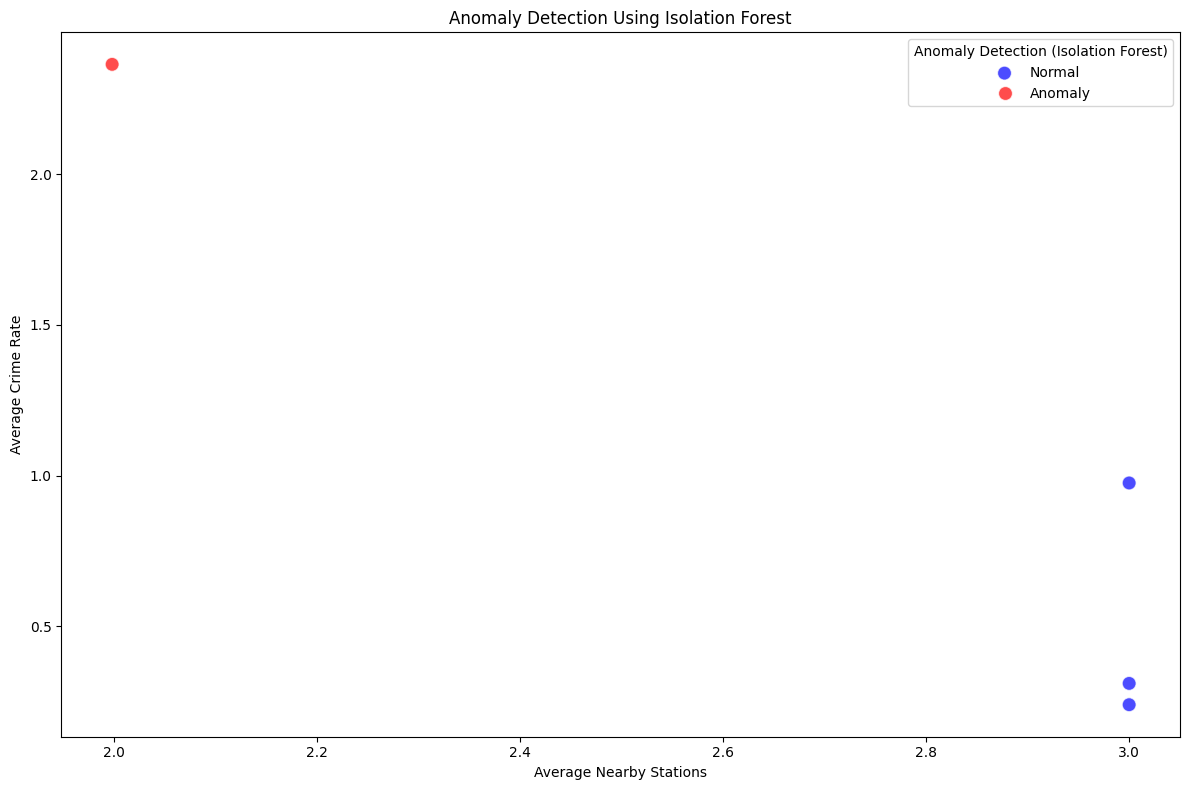

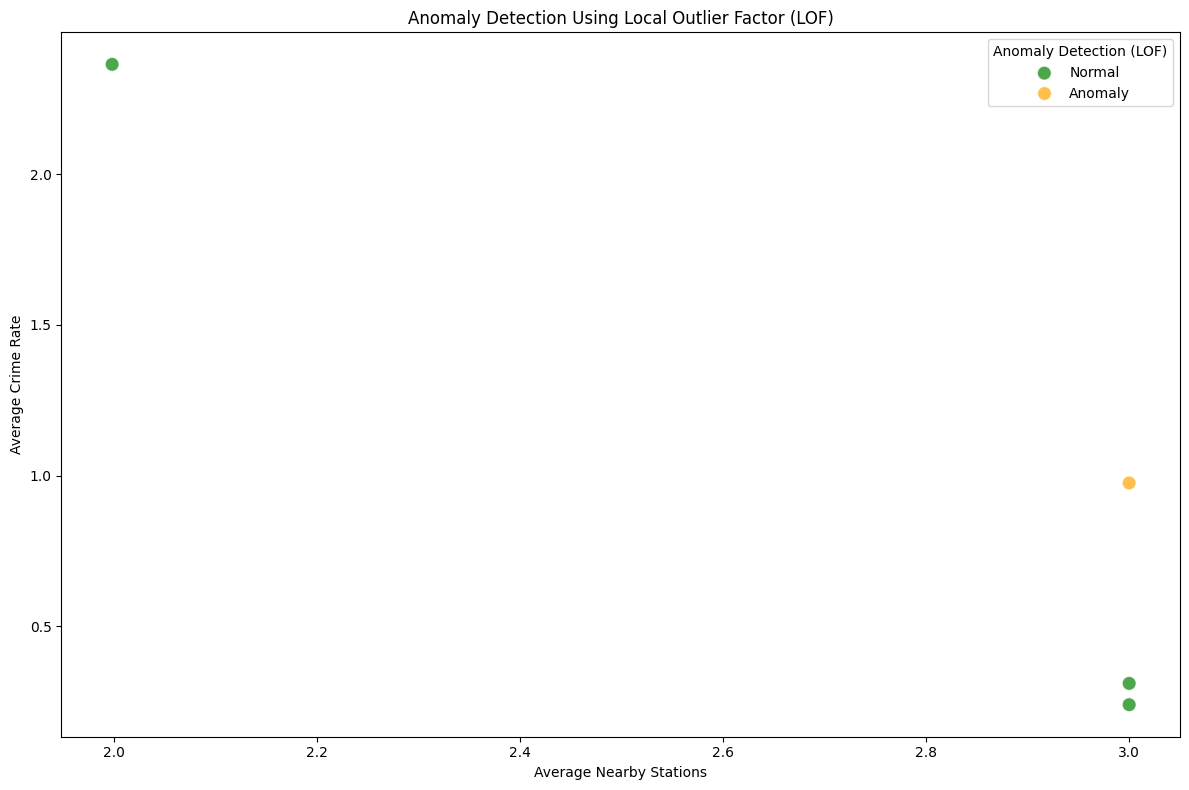

In [17]:
# Set font for Hebrew compatibility
plt.rcParams['font.family'] = 'DejaVu Sans'

# Step 1: Anomaly Detection with Isolation Forest
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=priority_yeshuvs_with_names['StationsNearbyAvg'],
    y=priority_yeshuvs_with_names['YeshuvCrimeRateAvg'],
    hue=priority_yeshuvs_with_names['Anomaly'],  # -1 for anomalies, 1 for normal
    palette={-1: 'red', 1: 'blue'},
    s=100,
    alpha=0.7)

plt.title("Anomaly Detection Using Isolation Forest")
plt.xlabel("Average Nearby Stations")
plt.ylabel("Average Crime Rate")
plt.legend(title="Anomaly Detection (Isolation Forest)", labels=["Normal", "Anomaly"])
plt.tight_layout()
plt.show()

# Step 2: Anomaly Detection with Local Outlier Factor (LOF)
from sklearn.neighbors import LocalOutlierFactor

# Adjust number of neighbors dynamically based on dataset size
n_neighbors = min(20, len(priority_yeshuvs_with_names) - 1)

# Train LOF model for anomaly detection
lof = LocalOutlierFactor(n_neighbors=n_neighbors, contamination=0.1)
priority_yeshuvs_with_names['Anomaly_LOF'] = lof.fit_predict(
    priority_yeshuvs_with_names[['YeshuvCrimeRateAvg', 'StationsNearbyAvg']])

# Scatter plot for LOF anomaly detection results
plt.figure(figsize=(12, 8))
sns.scatterplot(
    x=priority_yeshuvs_with_names['StationsNearbyAvg'],
    y=priority_yeshuvs_with_names['YeshuvCrimeRateAvg'],
    hue=priority_yeshuvs_with_names['Anomaly_LOF'],  # -1 for anomalies, 1 for normal
    palette={-1: 'orange', 1: 'green'},
    s=100,
    alpha=0.7)

plt.title("Anomaly Detection Using Local Outlier Factor (LOF)")
plt.xlabel("Average Nearby Stations")
plt.ylabel("Average Crime Rate")
plt.legend(title="Anomaly Detection (LOF)", labels=["Normal", "Anomaly"])
plt.tight_layout()
plt.show()